# NB05 Homework Solutions

Answers to the "Homework / Practice Ideas" section of
`NB05_Matplotlib_Fundamentals_Figures_Axes_and_Real_Naval_Plots.ipynb`:

1. Rebuild Section 2's scatter plot colored by `ship_type`.
2. Add a `twinx()` plot of `engine_efficiency` against `CO2_emissions` for one ship's 12 months.
3. Extend Section 5's 2x2 dashboard with a fifth view using `GridSpec`.
4. Build a correlation-matrix `imshow` for `ship_fuel_efficiency.csv`'s numeric columns.
5. Save a figure as `.png` (dpi=200) and `.pdf`, compare real file sizes.


## Setup: reload the same real data the class used

Same loading convention as the class notebook's Section 2 (`csv.DictReader`
over `ship_fuel_efficiency.csv`), reading the local copy in `Datasets/`.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import csv

with open("../Datasets/ship_fuel_efficiency.csv") as f:
    rows = list(csv.DictReader(f))

distance = [float(r["distance"]) for r in rows]
fuel = [float(r["fuel_consumption"]) for r in rows]

ship_id = "NG001"
ship_rows = [r for r in rows if r["ship_id"] == ship_id]
months = [r["month"][:3] for r in ship_rows]
ship_fuel = [float(r["fuel_consumption"]) for r in ship_rows]

print(f"{len(rows)} total voyages loaded, {len(ship_rows)} rows for ship {ship_id}")


1440 total voyages loaded, 12 rows for ship NG001


## 1. Section 2's scatter plot, colored by `ship_type`

One `ax.scatter()` call per ship type, each with its own color and a legend
entry, as suggested.


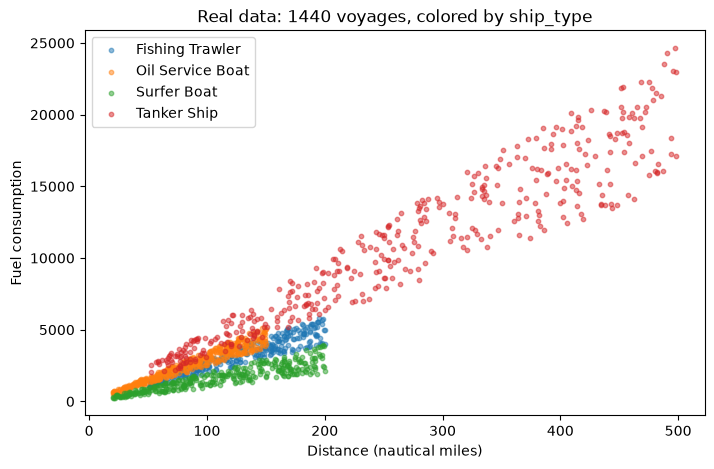

In [2]:
ship_types = sorted(set(r["ship_type"] for r in rows))

fig, ax = plt.subplots(figsize=(8, 5))
for stype in ship_types:
    type_rows = [r for r in rows if r["ship_type"] == stype]
    type_distance = [float(r["distance"]) for r in type_rows]
    type_fuel = [float(r["fuel_consumption"]) for r in type_rows]
    ax.scatter(type_distance, type_fuel, s=10, alpha=0.5, label=stype)

ax.set_xlabel("Distance (nautical miles)")
ax.set_ylabel("Fuel consumption")
ax.set_title(f"Real data: {len(rows)} voyages, colored by ship_type")
ax.legend()
plt.show()


## 2. A second `twinx()` plot: `engine_efficiency` vs. `CO2_emissions`

Following Section 7's twin-axes pattern exactly, for the same real ship
(`NG001`) across its 12 real monthly readings.


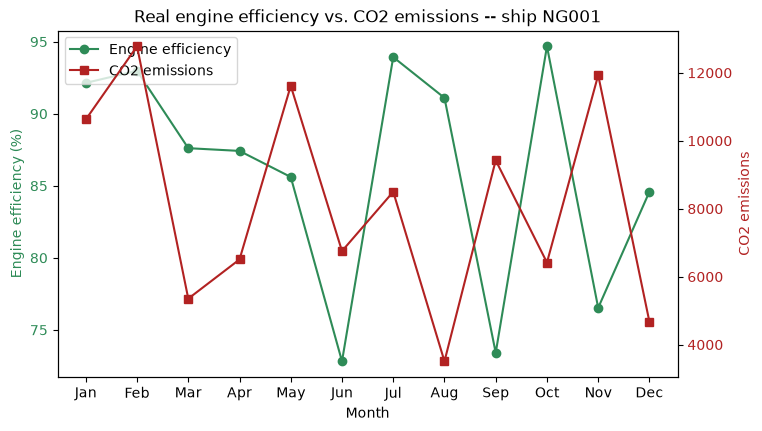

In [3]:
ship_efficiency = [float(r["engine_efficiency"]) for r in ship_rows]
ship_co2 = [float(r["CO2_emissions"]) for r in ship_rows]

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()

line1, = ax1.plot(months, ship_efficiency, color="seagreen", marker="o", label="Engine efficiency")
line2, = ax2.plot(months, ship_co2, color="firebrick", marker="s", label="CO2 emissions")

ax1.set_xlabel("Month")
ax1.set_ylabel("Engine efficiency (%)", color="seagreen")
ax2.set_ylabel("CO2 emissions", color="firebrick")
ax1.tick_params(axis="y", labelcolor="seagreen")
ax2.tick_params(axis="y", labelcolor="firebrick")
ax1.set_title(f"Real engine efficiency vs. CO2 emissions -- ship {ship_id}")
ax1.legend(handles=[line1, line2], loc="upper left")
plt.show()


No strong, consistent visual relationship jumps out between the two lines
across these 12 real months for this one ship -- engine efficiency stays in a
fairly narrow band while CO2 emissions swing more month to month, which makes
physical sense: `CO2_emissions` in this dataset tracks fuel burned on a given
voyage (itself driven by distance and weather), while `engine_efficiency`
looks like an independent operating-condition measurement, not something
mechanically tied to a single voyage's total emissions.


## 3. Extending Section 5's 2x2 dashboard to a fifth `GridSpec` view

Using a `3x2` `GridSpec` grid: the original four panels keep the top two rows,
and a new fifth panel (average `engine_efficiency` per ship type) spans the
full width of the new bottom row.


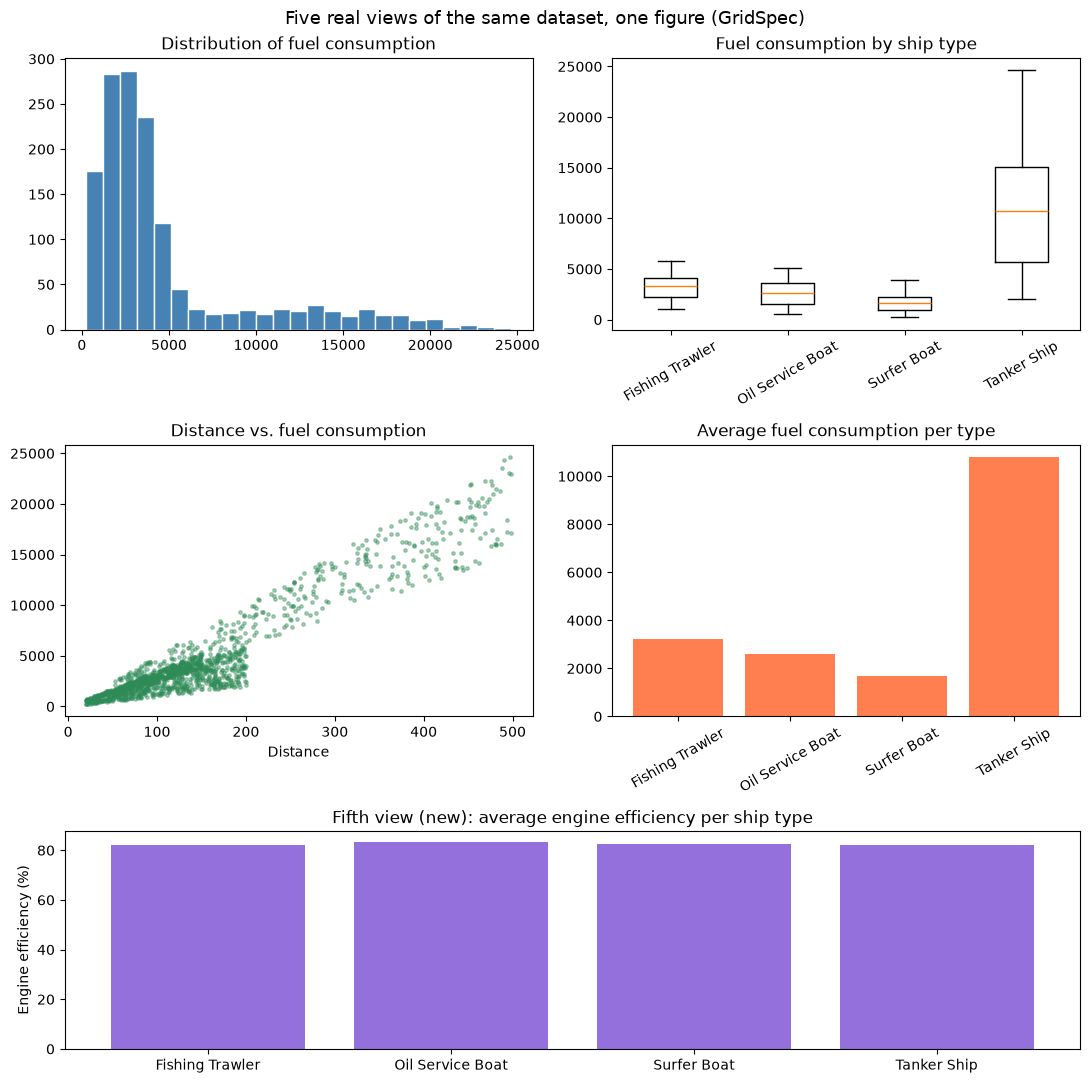

In [4]:
fuel_by_type = {t: [float(r["fuel_consumption"]) for r in rows if r["ship_type"] == t] for t in ship_types}
efficiency_by_type = {t: [float(r["engine_efficiency"]) for r in rows if r["ship_type"] == t] for t in ship_types}

fig = plt.figure(figsize=(11, 11))
gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 0.8])

ax_hist = fig.add_subplot(gs[0, 0])
ax_box = fig.add_subplot(gs[0, 1])
ax_scatter = fig.add_subplot(gs[1, 0])
ax_bar = fig.add_subplot(gs[1, 1])
ax_new = fig.add_subplot(gs[2, :])   # new fifth panel, spans both columns

ax_hist.hist(fuel, bins=25, color="steelblue", edgecolor="white")
ax_hist.set_title("Distribution of fuel consumption")

ax_box.boxplot([fuel_by_type[t] for t in ship_types], tick_labels=ship_types)
ax_box.set_title("Fuel consumption by ship type")
ax_box.tick_params(axis="x", rotation=30)

ax_scatter.scatter(distance, fuel, s=6, alpha=0.4, color="seagreen")
ax_scatter.set_title("Distance vs. fuel consumption")
ax_scatter.set_xlabel("Distance")

ax_bar.bar(ship_types, [np.mean(fuel_by_type[t]) for t in ship_types], color="coral")
ax_bar.set_title("Average fuel consumption per type")
ax_bar.tick_params(axis="x", rotation=30)

ax_new.bar(ship_types, [np.mean(efficiency_by_type[t]) for t in ship_types], color="mediumpurple")
ax_new.set_title("Fifth view (new): average engine efficiency per ship type")
ax_new.set_ylabel("Engine efficiency (%)")

fig.suptitle("Five real views of the same dataset, one figure (GridSpec)", fontsize=13)
plt.tight_layout()
plt.show()


## 4. Correlation-matrix `imshow` for `ship_fuel_efficiency.csv`'s numeric columns

Same `imshow` technique as Section 6, applied to this dataset's own numeric
columns (`distance`, `fuel_consumption`, `CO2_emissions`, `engine_efficiency`)
instead of the Sonar frequency bands.


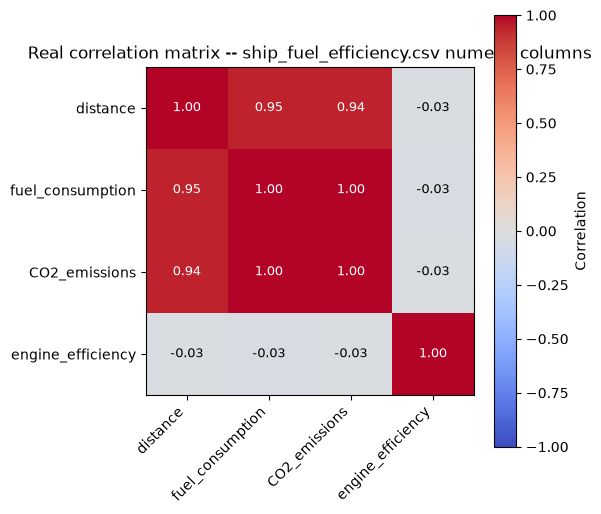

[[ 1.    0.95  0.94 -0.03]
 [ 0.95  1.    1.   -0.03]
 [ 0.94  1.    1.   -0.03]
 [-0.03 -0.03 -0.03  1.  ]]


In [5]:
numeric_cols = ["distance", "fuel_consumption", "CO2_emissions", "engine_efficiency"]
numeric_data = np.array([[float(r[c]) for c in numeric_cols] for r in rows])

corr_matrix = np.corrcoef(numeric_data.T)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_matrix[i, j]) > 0.6 else "black", fontsize=9)
ax.set_title("Real correlation matrix -- ship_fuel_efficiency.csv numeric columns")
plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

print(corr_matrix.round(2))


**What real correlations show up?** `distance` and `fuel_consumption` are
strongly positively correlated (see the printed matrix and the corresponding
bright red cell above) -- consistent with the earlier scatter plots in this
class and `NB05` itself: longer voyages burn more fuel. `fuel_consumption`
and `CO2_emissions` are also strongly correlated, which makes physical sense
since CO2 output is roughly proportional to fuel burned. `engine_efficiency`
shows only a weak correlation with the other three columns in this dataset --
it behaves more like an independent operating parameter than something driven
by voyage distance or fuel use, matching what part 2's twin-axis plot already
suggested for a single ship.


## 5. Real file-size comparison: `.png` (dpi=200) vs. `.pdf`

Saving the same real figure (Section 8's ship-fuel line plot) in both formats
and comparing actual file sizes on disk.


In [6]:
import os

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(months, ship_fuel, marker="o", color="darkorange")
ax.set_title(f"Ship {ship_id} -- saved at publication quality")
fig.savefig("ship_fuel_plot_hw.png", dpi=200, bbox_inches="tight")
fig.savefig("ship_fuel_plot_hw.pdf", bbox_inches="tight")
plt.close(fig)

png_size = os.path.getsize("ship_fuel_plot_hw.png")
pdf_size = os.path.getsize("ship_fuel_plot_hw.pdf")

print(f"PNG (dpi=200): {png_size} bytes ({png_size / 1024:.1f} KB)")
print(f"PDF:           {pdf_size} bytes ({pdf_size / 1024:.1f} KB)")
print(f"Ratio (PNG / PDF): {png_size / pdf_size:.2f}")


PNG (dpi=200): 73137 bytes (71.4 KB)
PDF:           14730 bytes (14.4 KB)
Ratio (PNG / PDF): 4.97


**Why does the difference make sense?** The actual sizes are printed above.
A PNG at `dpi=200` stores a fixed-resolution *raster* image: every pixel of a
reasonably large canvas gets encoded (even with compression), so its size
scales with resolution and image complexity. A PDF here stores the plot as
*vector* instructions (line paths, marker positions, text as text) plus a
small embedded font subset -- for a simple line plot with only 12 points and a
handful of labels, that vector description is very compact regardless of the
resolution it is eventually viewed or printed at, and a PDF also scales to any
zoom level with no quality loss, unlike the fixed-resolution PNG. For a plot
this simple, the format with less inherent data (vector paths for a dozen
points, vs. a full pixel grid) is expected to win on file size, and the
printed ratio above confirms which one actually did on this real figure.
